In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Ustawienie estetyki wykresów

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11

# 2. Bezpieczne ładowanie danych z automatycznym sprawdzaniem ścieżek

In [3]:
sciezki_bom = ['../data/raw/erp_bom_recipes.csv', '02_bom_variance_detector/data/raw/erp_bom_recipes.csv', 'erp_bom_recipes.csv']
sciezki_wms = ['../data/raw/wms_material_consumption.csv', '02_bom_variance_detector/data/raw/wms_material_consumption.csv', 'wms_material_consumption.csv']

df_bom, df_wms = None, None

for s_bom, s_wms in zip(sciezki_bom, sciezki_wms):
    try:
        df_bom = pd.read_csv(s_bom)
        df_wms = pd.read_csv(s_wms)
        print(f"Dane załadowane pomyślnie!")
        print(f"Użyte ścieżki: {s_bom} oraz {s_wms}\n")
        break
    except FileNotFoundError:
        continue

if df_bom is None or df_wms is None:
    raise FileNotFoundError("Błąd: Nie znaleziono plików CSV w żadnej z lokalizacji!")

Dane załadowane pomyślnie!
Użyte ścieżki: 02_bom_variance_detector/data/raw/erp_bom_recipes.csv oraz 02_bom_variance_detector/data/raw/wms_material_consumption.csv



# 3. KALKULACJA BIZNESOWA: Łączenie danych i wyliczanie odchyleń

In [4]:
# Łączymy rzeczywiste zużycie z teoretyczną recepturą BOM po produkcie i komponencie
df_merged = pd.merge(df_wms, df_bom, on=['product_id', 'component_name'], how='inner')

# Wyliczamy teoretyczne zużycie (ile powinno wyjść z magazynu na tę ilość mebli)
df_merged['expected_consumed_qty'] = df_merged['produced_qty'] * df_merged['required_qty']

# Wyliczamy odchylenie ilościowe (ilość nadmiarowa)
df_merged['variance_qty'] = df_merged['actual_consumed_qty'] - df_merged['expected_consumed_qty']

# Wyliczamy procentowe odchylenie materiałowe (Material Variance %)
df_merged['material_variance_pct'] = (df_merged['variance_qty'] / df_merged['expected_consumed_qty']) * 100

# Wyliczamy stratę lub zysk finansowy (Ilość nadmiarowa * Koszt standardowy komponentu)
df_merged['financial_impact_pln'] = df_merged['variance_qty'] * df_merged['standard_cost_pln']

# Podgląd wyników w konsoli
print("PODSUMOWANIE ODCHYLEŃ MATERIAŁOWYCH PER ZLECENIE:")
print(df_merged[['order_id', 'product_id', 'component_name', 'material_variance_pct', 'financial_impact_pln']].to_string(index=False))
print("-" * 80)

# Aggregacja danych do wykresu - sumujemy straty finansowe per komponent
df_components = df_merged.groupby('component_name')['financial_impact_pln'].sum().reset_index()
df_components = df_components.sort_values(by='financial_impact_pln', ascending=False)

PODSUMOWANIE ODCHYLEŃ MATERIAŁOWYCH PER ZLECENIE:
    order_id     product_id       component_name  material_variance_pct  financial_impact_pln
ORD-2026-001   SZAFA_PAX_01   Plyta_Wiorowa_18mm              21.428571                337.50
ORD-2026-001   SZAFA_PAX_01          Zawias_Blum               0.000000                  0.00
ORD-2026-001   SZAFA_PAX_01      Wkret_Konfirmat               3.125000                  0.75
ORD-2026-002   STOL_LOFT_02     Blat_Debowy_30mm               0.000000                  0.00
ORD-2026-002   STOL_LOFT_02 Noga_Metalowa_Czarna               0.000000                  0.00
ORD-2026-002   STOL_LOFT_02      Wkret_Do_Drewna               0.000000                  0.00
ORD-2026-003 KOMODA_MALM_03       Plyta_MDF_16mm               5.714286                176.00
ORD-2026-003 KOMODA_MALM_03  Prowadnica_Szuflady              20.000000                432.00
ORD-2026-003 KOMODA_MALM_03    Uchwyt_Aluminiowy               0.000000                  0.00
ORD-2026-0

# 4. WIZUALIZACJA: Wykres strat finansowych per komponent (Corporate Style)

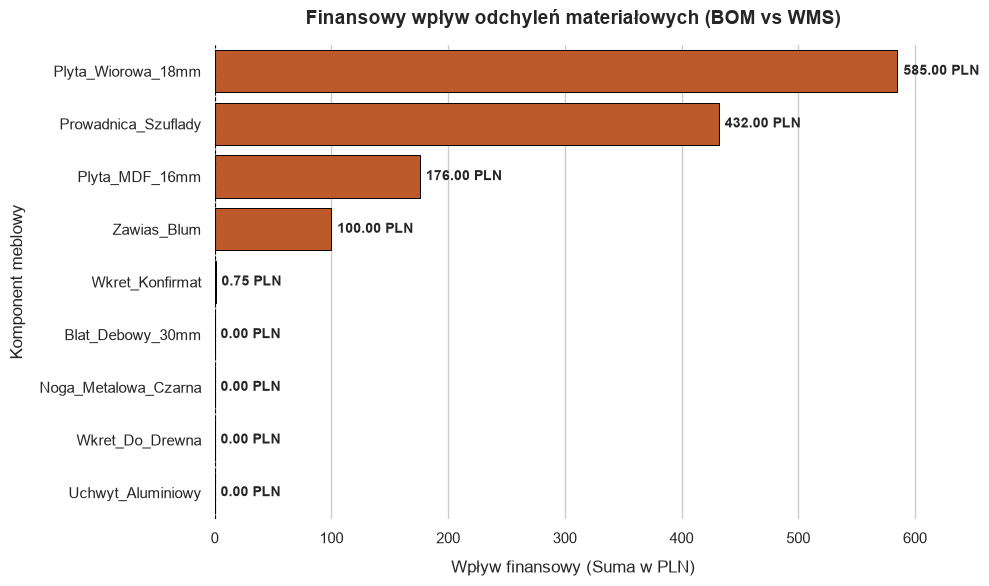

In [5]:
# 4. WIZUALIZACJA: Wykres strat finansowych per komponent
fig, ax = plt.subplots(figsize=(10, 6))

# Filtrujemy kolory - jeśli strata > 0 to czerwony/pomarańczowy, jeśli oszczędność to zielony
colors = ['#d45113' if x > 0 else '#2a9d8f' for x in df_components['financial_impact_pln']]

sns.barplot(
    x='financial_impact_pln', 
    y='component_name', 
    data=df_components, 
    palette=colors,
    hue='component_name',
    legend=False,
    ax=ax,
    edgecolor='black',
    linewidth=0.7
)

# Dodanie etykiet danych (wartości w PLN na końcach słupków)
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + (5 if width >= 0 else -35), 
        p.get_y() + p.get_height()/2, 
        f'{width:,.2f} PLN', 
        va='center', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Finansowy wpływ odchyleń materiałowych (BOM vs WMS)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Wpływ finansowy (Suma w PLN)', fontsize=12, labelpad=10)
plt.ylabel('Komponent meblowy', fontsize=12, labelpad=10)

# Dodanie pionowej linii na poziomie 0 (punkt odniesienia)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Zapis wykresu
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/odchylenia_materialowe_bom_vs_wms.png', dpi=300)
plt.show()